## Patient Adherence & Healthcare Analytics

In [91]:
import pandas as pd

df = pd.read_csv("C:/Users/HAPPY/Downloads/patient_adherence_analytics_updated.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 5000 non-null   object 
 1   Age                        5000 non-null   int64  
 2   Gender                     5000 non-null   object 
 3   City                       5000 non-null   object 
 4   State                      5000 non-null   object 
 5   Region                     5000 non-null   object 
 6   BMI                        5000 non-null   float64
 7   Disease                    5000 non-null   object 
 8   Disease_Severity           5000 non-null   object 
 9   Treatment_Duration_Months  5000 non-null   int64  
 10  Monthly_Income             5000 non-null   int64  
 11  Insurance                  5000 non-null   object 
 12  Hospital                   5000 non-null   object 
 13  Doctor_ID                  5000 non-null   objec

In [92]:
df.describe()

,Age,BMI,Treatment_Duration_Months,Monthly_Income,Doctor_Experience,Followup_Calls,Distance_From_Hospital_km,Satisfaction_Score,Prescription_Renewals,Missed_Doses,Adherence_Score,Campaign_Cost,Monthly_Revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,50.454000,27.018900,12.476600,50202.269600,16.069200,2.267600,12.494480,3.710580,3.475800,3.080800,68.819800,18.429349,129.676005
std,17.382218,3.991184,6.831221,18062.773954,8.302012,1.794836,7.303733,0.625438,1.052823,2.524509,17.581034,7.373611,22.599564
min,20.000000,13.400000,1.000000,-24839.000000,2.000000,0.000000,0.000000,1.700000,1.000000,0.000000,20.000000,3.784360,63.033640
25%,36.000000,24.300000,7.000000,38057.000000,9.000000,1.000000,6.900000,3.300000,3.000000,1.000000,54.000000,12.443726,113.677872
50%,50.000000,27.000000,12.500000,50102.000000,16.000000,2.000000,12.100000,3.700000,4.000000,3.000000,73.000000,16.099133,131.555598
75%,66.000000,29.800000,18.000000,62647.500000,23.000000,3.000000,17.400000,4.200000,4.000000,5.000000,83.000000,26.601382,146.770088
max,80.000000,41.500000,24.000000,114790.000000,30.000000,12.000000,39.200000,5.000000,6.000000,12.000000,100.000000,34.690949,187.530703


In [93]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [94]:
df.head()

df.shape

df.info()

df.describe()

df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 5000 non-null   object 
 1   Age                        5000 non-null   int64  
 2   Gender                     5000 non-null   object 
 3   City                       5000 non-null   object 
 4   State                      5000 non-null   object 
 5   Region                     5000 non-null   object 
 6   BMI                        5000 non-null   float64
 7   Disease                    5000 non-null   object 
 8   Disease_Severity           5000 non-null   object 
 9   Treatment_Duration_Months  5000 non-null   int64  
 10  Monthly_Income             5000 non-null   int64  
 11  Insurance                  5000 non-null   object 
 12  Hospital                   5000 non-null   object 
 13  Doctor_ID                  5000 non-null   objec

,Patient_ID,Gender,City,State,Region,Disease,Disease_Severity,Insurance,Hospital,Doctor_ID,Medicine,Side_Effects,Reminder_App,Patient_Support_Program,Adherence_Status,Campaign_Exposure,Marketing_Channel,Support_Contacted,Consultation_Attended
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3270,5000,5000,5000,5000,5000,5000,5000
unique,5000,2,10,9,4,2,3,2,15,100,1,3,2,2,2,2,5,2,2
top,P00001,Female,Kolkata,Maharashtra,West,Diabetes,Mild,Yes,Hospital_3,D055,Drug X,Mild,Yes,Yes,Adherent,Yes,Doctor Referral,Yes,Yes
freq,1,2531,522,1014,1506,2522,1995,2555,368,73,5000,1795,3236,3001,2748,3373,1657,2941,3011


In [19]:
df.isnull().sum()

Patient_ID                   0
Age                          0
Gender                       0
City                         0
State                        0
Region                       0
BMI                          0
Disease                      0
Disease_Severity             0
Treatment_Duration_Months    0
Monthly_Income               0
Insurance                    0
Hospital                     0
Doctor_ID                    0
Doctor_Experience            0
Medicine                     0
Side_Effects                 0
Reminder_App                 0
Followup_Calls               0
Patient_Support_Program      0
Distance_From_Hospital_km    0
Satisfaction_Score           0
Prescription_Renewals        0
Missed_Doses                 0
Adherence_Score              0
Adherence_Status             0
dtype: int64

In [95]:
df.duplicated().sum()

0

In [96]:
df["Side_Effects"] = df["Side_Effects"].fillna("No Effect")

In [97]:
print(df["Side_Effects"].value_counts(dropna=False))

Side_Effects
Mild         1795
No Effect    1730
Moderate      958
Severe        517
Name: count, dtype: int64


## Exploratory Data Analysis

In [98]:
# What is the overall adherence rate?
adherent = (df["Adherence_Status"] == "Adherent").sum()
non_adherent = (df["Adherence_Status"] == "Non-Adherent").sum()

print(adherent)
print(non_adherent)

print(df["Adherence_Status"].value_counts(normalize=True)*100)
print ("Average Adherence Score :")
df["Adherence_Score"].mean()

2748
2252
Adherence_Status
Adherent        54.96
Non-Adherent    45.04
Name: proportion, dtype: float64
Average Adherence Score :


68.8198

In [99]:
# Average satisfaction
df["Satisfaction_Score"].mean()

3.71058

In [100]:
# Reminder App adoption
df["Reminder_App"].value_counts()

df["Reminder_App"].value_counts(normalize=True)*100

Reminder_App
Yes    64.72
No     35.28
Name: proportion, dtype: float64

In [101]:
# Patient Support Program
df["Patient_Support_Program"].value_counts()

df["Patient_Support_Program"].value_counts(normalize=True)*100

Patient_Support_Program
Yes    60.02
No     39.98
Name: proportion, dtype: float64

In [34]:
# Average Follow-up Calls
df["Followup_Calls"].mean()

2.2676

In [35]:
# Average Missed Doses
df["Missed_Doses"].mean()

3.0808

In [46]:
print("Disease Distribution")
df["Disease"].value_counts()


Disease Distribution


Disease
Diabetes        2522
Hypertension    2478
Name: count, dtype: int64

In [45]:

df["Disease_Severity"].value_counts()

Disease_Severity
Mild        1995
Moderate    1963
Severe      1042
Name: count, dtype: int64

In [48]:
print("Average Distance from Hospital")
round(df["Distance_From_Hospital_km"].mean(),2)


Average Distance from Hospital


12.49

## Business Analytics

## Reminder App Effect on Patients

In [50]:
df.groupby("Reminder_App")["Adherence_Score"].mean()


Reminder_App
No     48.811224
Yes    79.726823
Name: Adherence_Score, dtype: float64

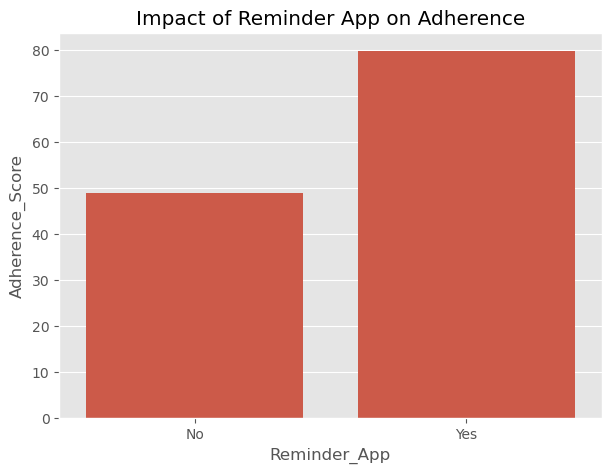

In [83]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Reminder_App",
    y="Adherence_Score",
    errorbar=None
)

plt.title("Impact of Reminder App on Adherence")

plt.show()

In [51]:
df.groupby("Reminder_App")["Missed_Doses"].mean()

Reminder_App
No     5.545918
Yes    1.737021
Name: Missed_Doses, dtype: float64

In [52]:
df.groupby("Reminder_App")["Satisfaction_Score"].mean()

Reminder_App
No     3.194955
Yes    3.991656
Name: Satisfaction_Score, dtype: float64

In [53]:
df.groupby("Adherence_Status")["Followup_Calls"].mean()

Adherence_Status
Adherent        3.123362
Non-Adherent    1.223357
Name: Followup_Calls, dtype: float64

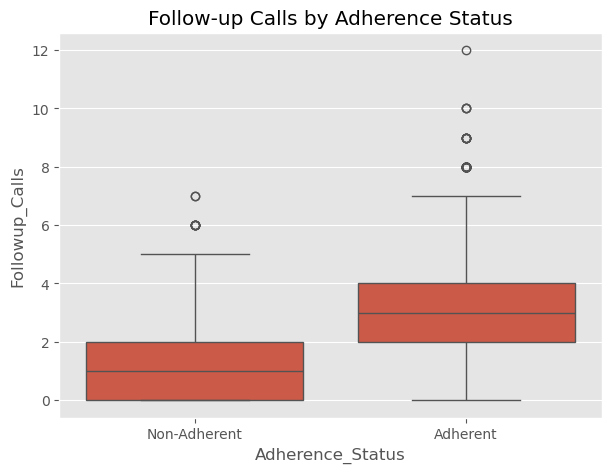

In [81]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Adherence_Status",
    y="Followup_Calls"
)

plt.title("Follow-up Calls by Adherence Status")

plt.show()

## Severe side effects causes

In [54]:
df.groupby("Side_Effects")["Adherence_Score"].mean()

Side_Effects
Mild         70.225070
Moderate     63.456159
No Effect    74.560694
Severe       54.669246
Name: Adherence_Score, dtype: float64

In [55]:
df.groupby("Side_Effects")["Missed_Doses"].mean()

Side_Effects
Mild         3.054039
Moderate     3.000000
No Effect    3.149133
Severe       3.094778
Name: Missed_Doses, dtype: float64

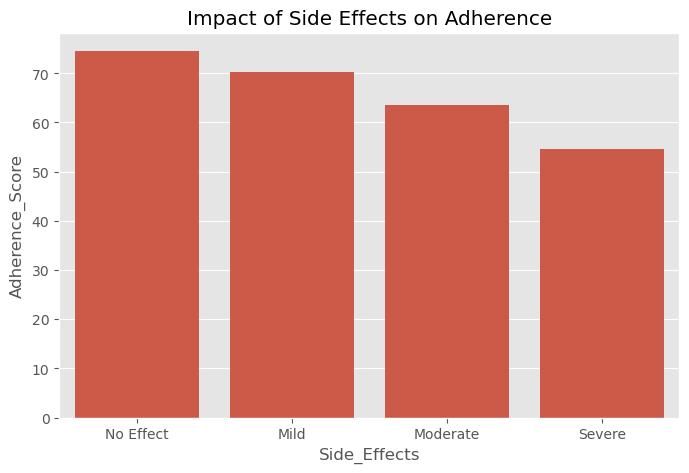

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Side_Effects",
    y="Adherence_Score",
    errorbar=None,
    order=["No Effect","Mild","Moderate","Severe"]
)

plt.title("Impact of Side Effects on Adherence")

plt.show()

## Rankings

In [56]:
df.groupby("Hospital")["Adherence_Score"].mean().sort_values(ascending=False)

Hospital
Hospital_2     69.924242
Hospital_14    69.834375
Hospital_4     69.571014
Hospital_1     69.498525
Hospital_13    69.387692
Hospital_9     69.333333
Hospital_5     69.155224
Hospital_7     68.876081
Hospital_15    68.656347
Hospital_3     68.567935
Hospital_8     68.487106
Hospital_6     68.485030
Hospital_10    67.978193
Hospital_11    67.315457
Hospital_12    67.296830
Name: Adherence_Score, dtype: float64

In [57]:
df.groupby("Doctor_ID")["Adherence_Score"].mean().sort_values(ascending=False)

Doctor_ID
D050    73.857143
D040    73.720000
D086    73.641026
D043    73.589286
D060    73.227273
          ...    
D009    63.612245
D076    63.487179
D041    63.482143
D030    63.350877
D021    62.684211
Name: Adherence_Score, Length: 100, dtype: float64

In [58]:
df.groupby("Region")["Adherence_Score"].mean()

Region
East     67.160920
North    68.946112
South    68.760956
West     69.330677
Name: Adherence_Score, dtype: float64

In [61]:
df.nlargest(10, "Missed_Doses")

,Patient_ID,Age,Gender,City,State,Region,BMI,Disease,Disease_Severity,Treatment_Duration_Months,...,Side_Effects,Reminder_App,Followup_Calls,Patient_Support_Program,Distance_From_Hospital_km,Satisfaction_Score,Prescription_Renewals,Missed_Doses,Adherence_Score,Adherence_Status
1145,P01146,37,Female,Chennai,Tamil Nadu,South,33.6,Hypertension,Mild,4,...,Moderate,No,0,Yes,13.3,2.5,1,12,29,Non-Adherent
2005,P02006,38,Female,Bengaluru,Karnataka,South,27.9,Hypertension,Moderate,14,...,Mild,No,2,Yes,12.8,2.6,3,12,41,Non-Adherent
3205,P03206,43,Female,Kolkata,West Bengal,East,28.2,Hypertension,Moderate,6,...,Mild,No,4,No,16.5,3.7,1,12,39,Non-Adherent
3937,P03938,55,Male,Jaipur,Rajasthan,North,23.4,Diabetes,Moderate,22,...,Mild,No,1,No,11.6,2.6,2,12,29,Non-Adherent
783,P00784,63,Female,Hyderabad,Telangana,South,24.4,Hypertension,Moderate,18,...,Mild,No,0,No,16.4,3.1,2,11,30,Non-Adherent
2160,P02161,43,Male,Hyderabad,Telangana,South,24.7,Hypertension,Moderate,21,...,No Effect,No,0,Yes,11.2,3.6,3,11,48,Non-Adherent
2450,P02451,26,Female,Jaipur,Rajasthan,North,24.4,Diabetes,Moderate,22,...,Mild,No,2,Yes,11.2,3.3,2,11,45,Non-Adherent
2479,P02480,40,Female,Chennai,Tamil Nadu,South,28.8,Diabetes,Mild,23,...,No Effect,No,0,No,8.7,3.7,2,11,38,Non-Adherent
2845,P02846,62,Female,Bengaluru,Karnataka,South,25.7,Diabetes,Mild,11,...,Moderate,No,2,No,16.4,3.9,1,11,31,Non-Adherent
2887,P02888,33,Female,Kolkata,West Bengal,East,30.9,Diabetes,Moderate,4,...,Mild,No,2,No,10.8,3.1,2,11,34,Non-Adherent


In [62]:
pd.pivot_table(
    df,
    values="Adherence_Score",
    index="Region",
    columns="Disease"
)

Disease,Diabetes,Hypertension
Region,,
East,67.851145,66.465385
North,69.034722,68.860590
South,69.606218,67.871935
West,69.251302,69.413279


In [63]:
pd.crosstab(
    df["Reminder_App"],
    df["Adherence_Status"]
)

Adherence_Status,Adherent,Non-Adherent
Reminder_App,,
No,6,1758
Yes,2742,494


## Risk Categorisation

In [66]:

conditions = [
    (df["Adherence_Score"] >= 85),
    (df["Adherence_Score"] >= 70),
    (df["Adherence_Score"] < 70)
]

choices = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

df["Risk_Category"] = np.select(conditions, choices)
df["Risk_Category"].value_counts()

Risk_Category
High Risk      2252
Medium Risk    1667
Low Risk       1081
Name: count, dtype: int64

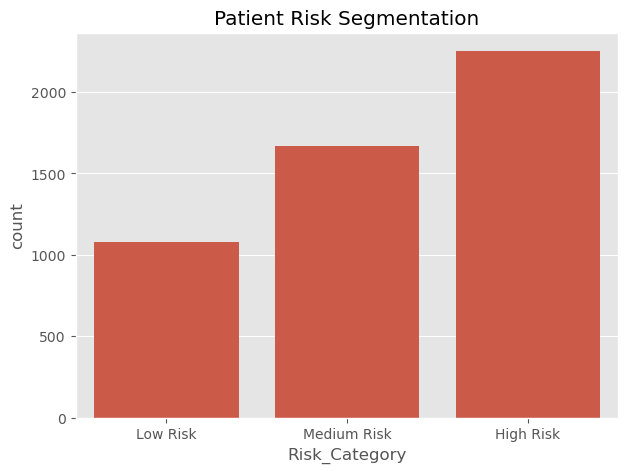

In [84]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Risk_Category",
    data=df,
    order=["Low Risk","Medium Risk","High Risk"]
)

plt.title("Patient Risk Segmentation")

plt.show()

## KPI Dashboard

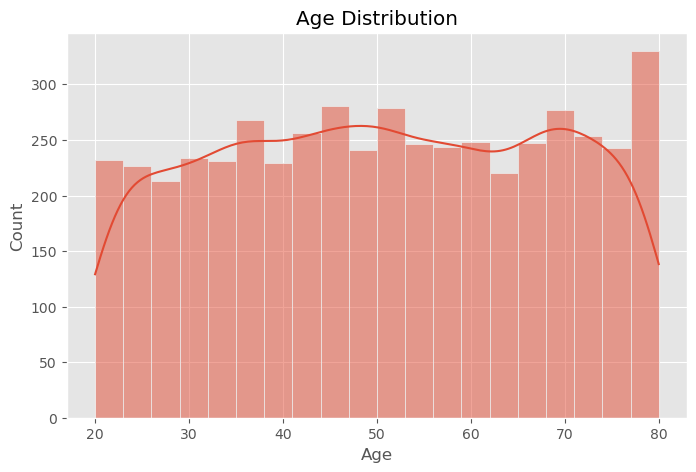

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

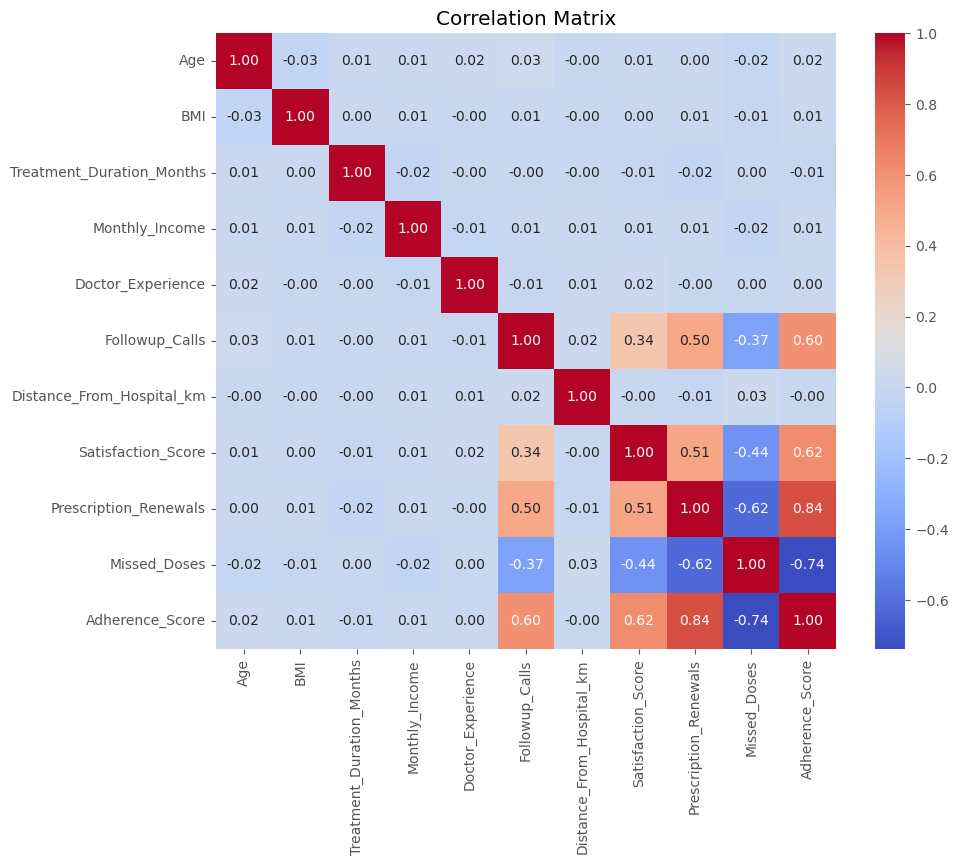

In [77]:
plt.figure(figsize=(10,8))

corr=df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [70]:
total_patients = len(df)

adherence_rate = (df["Adherence_Status"]=="Adherent").mean()*100

avg_adherence = df["Adherence_Score"].mean()

avg_satisfaction = df["Satisfaction_Score"].mean()

avg_followups = df["Followup_Calls"].mean()

avg_missed = df["Missed_Doses"].mean()

avg_renewals = df["Prescription_Renewals"].mean()

reminder_usage = (df["Reminder_App"]=="Yes").mean()*100

support_program = (df["Patient_Support_Program"]=="Yes").mean()*100

insured = (df["Insurance"]=="Yes").mean()*100

In [69]:
print("*"*50)

print("PATIENT ADHERENCE KPI DASHBOARD")

print("*"*50)

print(f"Total Patients                : {total_patients}")

print(f"Overall Adherence Rate        : {adherence_rate:.2f}%")

print(f"Average Adherence Score       : {avg_adherence:.2f}")

print(f"Average Satisfaction Score    : {avg_satisfaction:.2f}")

print(f"Average Follow-up Calls       : {avg_followups:.2f}")

print(f"Average Missed Doses          : {avg_missed:.2f}")

print(f"Average Prescription Renewal  : {avg_renewals:.2f}")

print(f"Reminder App Usage            : {reminder_usage:.2f}%")

print(f"Patient Support Program       : {support_program:.2f}%")

print(f"Insurance Coverage            : {insured:.2f}%")

**************************************************
PATIENT ADHERENCE KPI DASHBOARD
**************************************************
Total Patients                : 5000
Overall Adherence Rate        : 54.96%
Average Adherence Score       : 68.82
Average Satisfaction Score    : 3.71
Average Follow-up Calls       : 2.27
Average Missed Doses          : 3.08
Average Prescription Renewal  : 3.48
Reminder App Usage            : 64.72%
Patient Support Program       : 60.02%
Insurance Coverage            : 51.10%


## Business Recommendations
Expand the reminder app to increase patient engagement.
Increase follow-up calls during the first three months of treatment.
Introduce structured support for patients reporting moderate or severe side effects.
Study high-performing hospitals and standardize their practices.
Prioritize high-risk patients for proactive outreach and counseling.

## Module 2 

## Marketing & Patient Support Analytics

In [105]:
campaign_rate = ( df['Campaign_Exposure'].value_counts(normalize=True)*100 )
campaign_rate

Campaign_Exposure
Yes    67.46
No     32.54
Name: proportion, dtype: float64

In [106]:
channel_adherence = ( df.groupby('Marketing_Channel')['Adherence_Score'] .mean() .sort_values(ascending=False) ) 
channel_adherence

Marketing_Channel
Doctor Referral    74.380205
WhatsApp           70.458716
Email              66.112676
SMS                64.062674
Social Media       59.313589
Name: Adherence_Score, dtype: float64

<Axes: title={'center': 'Average Adherence by Marketing Channel'}, xlabel='Marketing_Channel'>

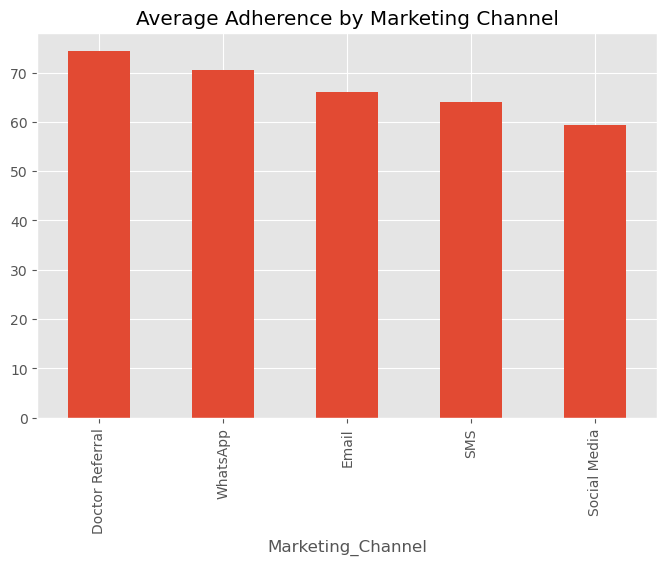

In [126]:
channel_adherence.plot(kind='bar', figsize=(8,5), title='Average Adherence by Marketing Channel')

## Campaign Effectiveness

In [107]:
df.groupby('Campaign_Exposure')['Adherence_Score'].mean()

Campaign_Exposure
No     58.357714
Yes    73.866291
Name: Adherence_Score, dtype: float64

<Axes: title={'center': 'Campaign Exposure vs Adherence'}, xlabel='Campaign_Exposure'>

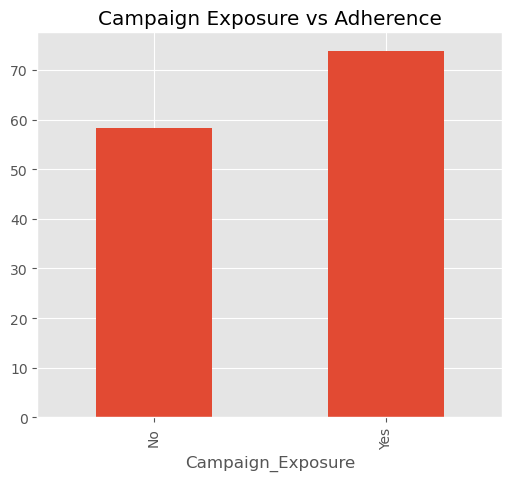

In [127]:
df.groupby('Campaign_Exposure')['Adherence_Score'].mean().plot(kind='bar', figsize=(6,5), title='Campaign Exposure vs Adherence')

In [108]:
df.groupby('Campaign_Exposure')['Satisfaction_Score'].mean()

Campaign_Exposure
No     3.449723
Yes    3.836407
Name: Satisfaction_Score, dtype: float64

In [109]:
df.groupby('Campaign_Exposure')['Missed_Doses'].mean()

Campaign_Exposure
No     4.430240
Yes    2.429884
Name: Missed_Doses, dtype: float64

Insights :
Exposed patients show higher adherence.

Exposed patients show higher satisfaction.

Exposed patients miss fewer doses.

## Revenue Analytics

In [115]:
df.groupby('Adherence_Status')['Monthly_Revenue'].mean()

Adherence_Status
Adherent        145.305137
Non-Adherent    110.604577
Name: Monthly_Revenue, dtype: float64

<Axes: title={'center': 'Revenue by Adherence Status'}, xlabel='Adherence_Status'>

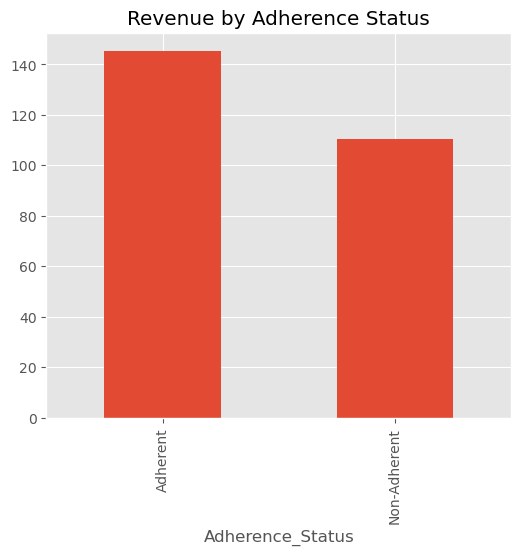

In [128]:
df.groupby('Adherence_Status')['Monthly_Revenue'].mean().plot(kind='bar', figsize=(6,5), title='Revenue by Adherence Status')

In [116]:
#Simple ROI Analysis
total_cost = df['Campaign_Cost'].sum() 
total_cost

92146.74595984895

In [117]:
adherent_revenue = ( df[df['Adherence_Status']=='Adherent']['Monthly_Revenue'] .sum() ) 
adherent_revenue

399298.517224072

In [119]:
roi = adherent_revenue / total_cost 
print(f'ROI Ratio: {roi:.2f}')

ROI Ratio: 4.33


##  High-Value Patient Segmentation

In [120]:
conditions = [ (df['Adherence_Score'] >= 85) & (df['Monthly_Revenue'] >= 80), (df['Adherence_Score'] >= 70), (df['Adherence_Score'] < 70) ] 
choices = ['High Value','Medium Value','At Risk']
df['Patient_Value_Segment'] = np.select(conditions, choices)
df['Patient_Value_Segment'].value_counts()

Patient_Value_Segment
At Risk         2252
Medium Value    1667
High Value      1081
Name: count, dtype: int64

In [121]:
pd.crosstab( df['Marketing_Channel'], df['Patient_Value_Segment'], normalize='index' )*100

Patient_Value_Segment,At Risk,High Value,Medium Value
Marketing_Channel,,,
Doctor Referral,26.614363,28.243814,45.141823
Email,53.521127,18.661972,27.816901
SMS,60.306407,15.738162,23.955432
Social Media,75.261324,9.407666,15.331010
WhatsApp,40.867389,23.936614,35.195997


<Axes: title={'center': 'Patient Value Segments'}, ylabel='count'>

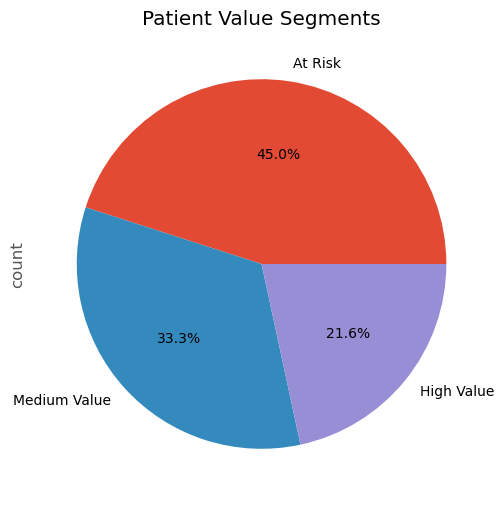

In [129]:
df['Patient_Value_Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title='Patient Value Segments')

## Regional Marketing Analysis

In [122]:
pd.pivot_table( df, values='Adherence_Score', index='Region', columns='Marketing_Channel' ).round(1)

Marketing_Channel,Doctor Referral,Email,SMS,Social Media,WhatsApp
Region,,,,,
East,72.9,64.3,63.4,54.4,68.7
North,73.8,66.8,64.8,59.3,70.5
South,75.0,65.4,63.4,59.4,70.6
West,74.9,66.9,64.2,60.6,70.7


In [125]:
marketing_kpis =  {'Campaign Reach %': round((df['Campaign_Exposure']=='Yes').mean()*100,2),
                  'Support Contact %': round((df['Support_Contacted']=='Yes').mean()*100,2),
                  'Consultation Attendance %': round((df['Consultation_Attended']=='Yes').mean()*100,2),
                  'Avg Revenue': round(df['Monthly_Revenue'].mean(),2), 'ROI Ratio': round(roi,2)} 
marketing_kpis

{'Campaign Reach %': 67.46,
 'Support Contact %': 58.82,
 'Consultation Attendance %': 60.22,
 'Avg Revenue': 129.68,
 'ROI Ratio': 4.33}

## Key Marketing Insights

Doctor Referral and WhatsApp channels show the strongest adherence outcomes.

Campaign-exposed patients demonstrate better adherence and satisfaction.

Patient support contact is associated with higher prescription renewals.

Consultation attendance is linked to improved adherence.

High-value patients contribute disproportionately to recurring revenue.

Prioritize high-value patient segments for retention initiatives.

Use region-specific channel strategies instead of a uniform national campaign.